# Housing Price Modelling Pipeline
Refined end-to-end notebook showing data preparation, modelling, comparison, and interpretation.

## 1. Imports and paths

In [1]:

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

pd.set_option('display.max_columns', 120)

project_dir = Path.cwd().resolve().parent
data_path = project_dir / "data" / "AmesHousing.csv"
output_dir = project_dir / "outputs"
output_dir.mkdir(exist_ok=True)


## 2. Load the dataset

In [2]:

housing = pd.read_csv(data_path)
housing.columns = (
    housing.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)
print("Rows, columns:", housing.shape)
housing.head()


Rows, columns: (2930, 82)


,order,pid,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,land_slope,neighborhood,condition_1,condition_2,bldg_type,house_style,overall_qual,overall_cond,year_built,year_remod_add,roof_style,roof_matl,exterior_1st,exterior_2nd,mas_vnr_type,mas_vnr_area,exter_qual,exter_cond,foundation,bsmt_qual,bsmt_cond,bsmt_exposure,bsmtfin_type_1,bsmtfin_sf_1,bsmtfin_type_2,bsmtfin_sf_2,bsmt_unf_sf,total_bsmt_sf,heating,heating_qc,central_air,electrical,1st_flr_sf,2nd_flr_sf,low_qual_fin_sf,gr_liv_area,bsmt_full_bath,bsmt_half_bath,full_bath,half_bath,bedroom_abvgr,kitchen_abvgr,kitchen_qual,totrms_abvgrd,functional,fireplaces,fireplace_qu,garage_type,garage_yr_blt,garage_finish,garage_cars,garage_area,garage_qual,garage_cond,paved_drive,wood_deck_sf,open_porch_sf,enclosed_porch,3ssn_porch,screen_porch,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,saleprice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 3. Create a focused modelling dataset

In [3]:

selected_columns = [
    "saleprice", "overall_qual", "gr_liv_area", "garage_area", "garage_cars",
    "total_bsmt_sf", "1st_flr_sf", "year_built", "year_remod_add",
    "full_bath", "totrms_abvgrd", "lot_area", "neighborhood", "house_style",
    "bldg_type", "central_air", "kitchen_qual", "exter_qual", "ms_zoning", "yr_sold"
]
selected_columns = [c for c in selected_columns if c in housing.columns]
model_df = housing[selected_columns].copy()
model_df.head()


,saleprice,overall_qual,gr_liv_area,garage_area,garage_cars,total_bsmt_sf,1st_flr_sf,year_built,year_remod_add,full_bath,totrms_abvgrd,lot_area,neighborhood,house_style,bldg_type,central_air,kitchen_qual,exter_qual,ms_zoning,yr_sold
0,215000,6,1656,528.0,2.0,1080.0,1656,1960,1960,1,7,31770,NAmes,1Story,1Fam,Y,TA,TA,RL,2010
1,105000,5,896,730.0,1.0,882.0,896,1961,1961,1,5,11622,NAmes,1Story,1Fam,Y,TA,TA,RH,2010
2,172000,6,1329,312.0,1.0,1329.0,1329,1958,1958,1,6,14267,NAmes,1Story,1Fam,Y,Gd,TA,RL,2010
3,244000,7,2110,522.0,2.0,2110.0,2110,1968,1968,2,8,11160,NAmes,1Story,1Fam,Y,Ex,Gd,RL,2010
4,189900,5,1629,482.0,2.0,928.0,928,1997,1998,2,6,13830,Gilbert,2Story,1Fam,Y,TA,TA,RL,2010


## 4. Feature engineering

In [4]:

model_df["house_age_at_sale"] = model_df["yr_sold"] - model_df["year_built"]
model_df["years_since_remodel"] = model_df["yr_sold"] - model_df["year_remod_add"]
model_df["total_bath_proxy"] = model_df["full_bath"]
model_df["space_per_room"] = np.where(model_df["totrms_abvgrd"] > 0, model_df["gr_liv_area"] / model_df["totrms_abvgrd"], np.nan)
model_df["garage_capacity_ratio"] = np.where(model_df["garage_cars"] > 0, model_df["garage_area"] / model_df["garage_cars"], np.nan)

model_df[["saleprice", "house_age_at_sale", "years_since_remodel", "space_per_room"]].describe().T


,count,mean,std,min,25%,50%,75%,max
saleprice,2930.0,180796.060068,79886.692357,12789.0,129500.0,160000.0,213500.00000,755000.0
house_age_at_sale,2930.0,36.434130,30.291357,-1.0,7.0,34.0,54.00000,136.0
years_since_remodel,2930.0,23.523891,20.858846,-2.0,4.0,15.0,42.75000,60.0
space_per_room,2930.0,231.609637,46.140007,120.0,199.0,226.5,257.61875,560.0


## 5. Data profile

In [5]:

profile = pd.DataFrame({
    "column": model_df.columns,
    "dtype": model_df.dtypes.astype(str).values,
    "missing_values": model_df.isna().sum().values,
    "missing_pct": (model_df.isna().mean().values * 100).round(2),
    "unique_values": [model_df[c].nunique() for c in model_df.columns]
}).sort_values(["missing_pct", "unique_values"], ascending=[False, False])

profile.to_csv(output_dir / "data_profile.csv", index=False)
profile


,column,dtype,missing_values,missing_pct,unique_values
24,garage_capacity_ratio,float64,158,5.39,529
5,total_bsmt_sf,float64,1,0.03,1058
3,garage_area,float64,1,0.03,603
4,garage_cars,float64,1,0.03,6
11,lot_area,int64,0,0.00,1960
23,space_per_room,float64,0,0.00,1631
2,gr_liv_area,int64,0,0.00,1292
6,1st_flr_sf,int64,0,0.00,1083
0,saleprice,int64,0,0.00,1032
20,house_age_at_sale,int64,0,0.00,128


## 6. Train/test split

In [6]:

X = model_df.drop(columns=["saleprice"])
y = model_df["saleprice"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Train shape: (2344, 24)
Test shape: (586, 24)
Numeric features: 17
Categorical features: 7


## 7. Preprocessing pipeline

In [7]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


## 8. Benchmark two interview-friendly models

In [8]:

models = {
    "linear_regression": LinearRegression(),
    "random_forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=16,
        min_samples_split=6,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
}

results = []
fitted_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    results.append({
        "model": name,
        "mae": mean_absolute_error(y_test, preds),
        "rmse": mean_squared_error(y_test, preds) ** 0.5,
        "r2": r2_score(y_test, preds),
    })
    fitted_models[name] = (pipeline, preds)

model_comparison = pd.DataFrame(results).sort_values("r2", ascending=False)
model_comparison.to_csv(output_dir / "model_comparison.csv", index=False)
model_comparison


,model,mae,rmse,r2
1,random_forest,17069.056517,30234.672747,0.885983
0,linear_regression,19157.007134,32457.652165,0.868601


## 9. Diagnostics for the best model

In [9]:

best_model_name = model_comparison.iloc[0]["model"]
best_pipeline, best_preds = fitted_models[best_model_name]

diagnostics = pd.DataFrame({
    "actual_saleprice": y_test.reset_index(drop=True),
    "predicted_saleprice": best_preds,
})
diagnostics["residual"] = diagnostics["actual_saleprice"] - diagnostics["predicted_saleprice"]
diagnostics["abs_error"] = diagnostics["residual"].abs()
diagnostics.to_csv(output_dir / "prediction_diagnostics.csv", index=False)

diagnostics.head()


,actual_saleprice,predicted_saleprice,residual,abs_error
0,161000,174667.421705,-13667.421705,13667.421705
1,116000,98846.970450,17153.029550,17153.029550
2,196500,195716.614194,783.385806,783.385806
3,123600,114539.729851,9060.270149,9060.270149
4,126000,112325.526063,13674.473937,13674.473937


## 10. Visualise model quality

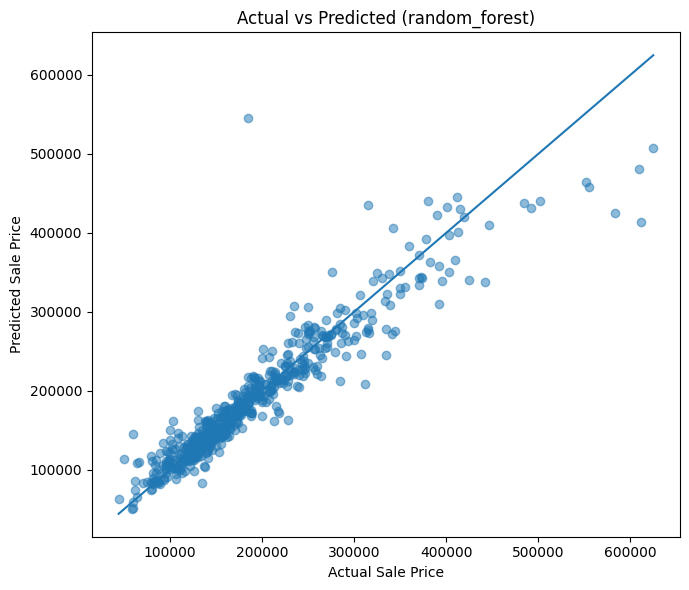

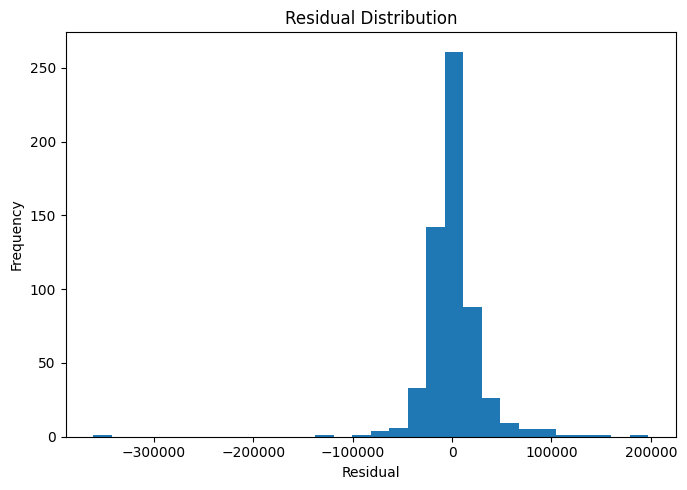

In [10]:

plt.figure(figsize=(7, 6))
plt.scatter(diagnostics["actual_saleprice"], diagnostics["predicted_saleprice"], alpha=0.5)
lims = [
    min(diagnostics["actual_saleprice"].min(), diagnostics["predicted_saleprice"].min()),
    max(diagnostics["actual_saleprice"].max(), diagnostics["predicted_saleprice"].max()),
]
plt.plot(lims, lims)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.tight_layout()
plt.savefig(output_dir / "actual_vs_predicted.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(diagnostics["residual"], bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.tight_layout()
plt.savefig(output_dir / "residual_distribution.png", dpi=150)
plt.show()


## 11. Feature importance

In [11]:

if best_model_name == "random_forest":
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = best_pipeline.named_steps["model"].feature_importances_
    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(15)
    )
else:
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
    coefs = np.abs(best_pipeline.named_steps["model"].coef_)
    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": coefs})
        .sort_values("importance", ascending=False)
        .head(15)
    )

importance_df.to_csv(output_dir / "top_feature_importance.csv", index=False)
importance_df


,feature,importance
0,num__overall_qual,0.623180
1,num__gr_liv_area,0.112964
5,num__1st_flr_sf,0.048223
4,num__total_bsmt_sf,0.035276
10,num__lot_area,0.023954
3,num__garage_cars,0.019288
15,num__space_per_room,0.019054
2,num__garage_area,0.018489
8,num__full_bath,0.011496
14,num__total_bath_proxy,0.009849


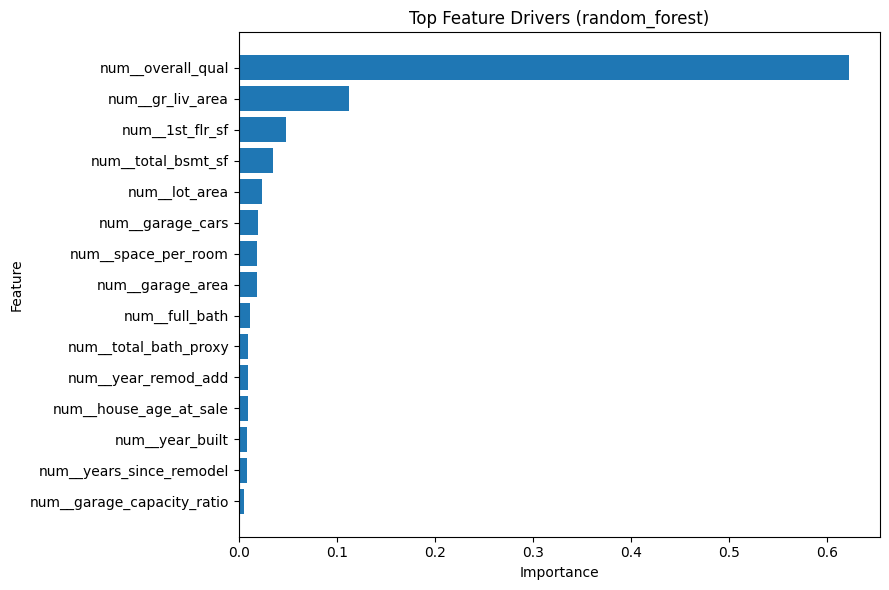

In [12]:

plt.figure(figsize=(9, 6))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top Feature Drivers ({best_model_name})")
plt.tight_layout()
plt.savefig(output_dir / "feature_importance.png", dpi=150)
plt.show()


## 12. Pricing segments for stakeholder interpretation

In [13]:

pricing_segments = pd.qcut(model_df["saleprice"], q=4, labels=["entry", "mid", "upper_mid", "premium"])
pricing_segment_summary = (
    model_df.assign(price_segment=pricing_segments)
    .groupby("price_segment", observed=False, as_index=False)
    .agg(
        homes=("price_segment", "size"),
        median_saleprice=("saleprice", "median"),
        median_living_area=("gr_liv_area", "median"),
        median_quality=("overall_qual", "median"),
        median_lot_area=("lot_area", "median"),
    )
)
pricing_segment_summary.to_csv(output_dir / "pricing_segment_summary.csv", index=False)
pricing_segment_summary


,price_segment,homes,median_saleprice,median_living_area,median_quality,median_lot_area
0,entry,739,110000.0,1048.0,5.0,7822.0
1,mid,728,144000.0,1227.0,5.0,9009.5
2,upper_mid,732,183100.0,1505.0,6.0,9600.0
3,premium,731,265900.0,1914.0,8.0,11520.0


## 13. Final summary

In [14]:

summary = {
    "best_model": best_model_name,
    "best_model_r2": round(float(model_comparison.iloc[0]["r2"]), 4),
    "best_model_rmse": round(float(model_comparison.iloc[0]["rmse"]), 2),
    "top_feature": importance_df.iloc[0]["feature"],
    "median_saleprice": round(float(model_df["saleprice"].median()), 2),
}

with open(output_dir / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary


{'best_model': 'random_forest',
 'best_model_r2': 0.886,
 'best_model_rmse': 30234.67,
 'top_feature': 'num__overall_qual',
 'median_saleprice': 160000.0}

## 14. Recommendations
- Use the benchmark comparison to explain why model selection matters.
- Use feature importance to discuss what drives valuation.
- Position this project as a practical example of preprocessing, modelling, and interpretation rather than just prediction.